# Part 3 — Text Classification Track 

**Project:** End-to-End NLP Pipeline for Drug Review Analysis  
**Dataset:** DrugLib train/test reviews

This notebook completes the text classification track by comparing:

1. a **baseline** using Multinomial Naive Bayes with TF-IDF Features, and  
2. an **advanced model** using transformer fine-tuning.

In [1]:
import os
import re
import html
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import nltk
except Exception:
    nltk = None

try:
    from nltk.sentiment import SentimentIntensityAnalyzer
except Exception:
    SentimentIntensityAnalyzer = None

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_colwidth", 140)


## 1. Load processed data

This notebook first tries to load the processed dataset from Part 1.  
If the processed file is not available, it rebuilds the minimum preprocessing steps directly from the raw DrugLib files.


In [15]:
PROCESSED_PATH = "data/druglib_outputs/processed/druglib_processed_combined.csv"
TRAIN_PATH = "data/druglib_outputs/processed/druglib_processed_train.csv"
TEST_PATH = "data/druglib_outputs/processed/druglib_processed_test.csv"

if os.path.exists(PROCESSED_PATH):
    df = pd.read_csv(PROCESSED_PATH)
    print("Loaded processed dataset:", PROCESSED_PATH)
else:
    print("Processed file not found. Rebuilding basic processed dataset from raw files.")
    train_df = pd.read_csv(TRAIN_PATH, sep="\t")
    test_df = pd.read_csv(TEST_PATH, sep="\t")
    train_df["split"] = "train"
    test_df["split"] = "test"
    df = pd.concat([train_df, test_df], ignore_index=True)

    review_columns = ["benefitsReview", "sideEffectsReview", "commentsReview"]
    df["full_review"] = df[review_columns].fillna("").agg(" ".join, axis=1)

    def rating_to_sentiment(rating):
        if rating <= 5:
            return "negative"
        else:
            return "positive"

    def clean_text(text):
        text = html.unescape(str(text))
        text = text.lower()
        text = re.sub(r"http\S+|www\S+", " ", text)
        text = re.sub(r"<.*?>", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    df["sentiment"] = df["rating"].apply(rating_to_sentiment)
    df["clean_review"] = df["full_review"].apply(clean_text)
    df["processed_review"] = df["clean_review"]

print(df.shape)
display(df[["split", "urlDrugName", "condition", "rating", "sentiment", "processed_review"]].head())


Loaded processed dataset: data/druglib_outputs/processed/druglib_processed_combined.csv
(4143, 18)


,split,urlDrugName,condition,rating,sentiment,processed_review
0,train,enalapril,management of congestive heart failure,4,negative,slowed progression left ventricular dysfunction overt heart failure alone agent managment hypertension mangagement congestive heart fail...
1,train,ortho-tri-cyclen,birth prevention,1,negative,although type birth control con pro help cramp also effective prevention pregnancy along use condom well heavy cycle cramp hot flash fat...
2,train,ponstel,menstrual cramps,10,positive,used cramp badly would leave balled bed least day ponstel take pain away completely take edge much normal activity possible definitely m...
3,train,prilosec,acid reflux,3,negative,acid reflux went away month day drug heartburn started soon stopped taking began treatment month passed stopped taking heartburn came ba...
4,train,lyrica,fibromyalgia,2,negative,think lyrica starting help pain side effect severe continue felt extremely drugged dopey could not drive med also extreme ankle foot swe...


## 2. Baseline: Multinomial Naive Bayes with TF-IDF Features

### Term based feature set using TF-IDF
Rating is fundamentally a sentiment/opinion signal, and that lives in adjectives, adverbs, negation, and phrasing — "worked wonders," "waste of money," "side effects were unbearable." TF-IDF unigrams/bigrams capture this directly. Drug names and condition entities, by contrast, tell you almost nothing about whether the review is positive or negative — the same drug entity shows up in 1-star and 10-star reviews alike.

In [17]:
# Check how many you're dealing with first
print(df['processed_review'].isna().sum())

# Drop rows with missing review text
df = df.dropna(subset=['processed_review']).reset_index(drop=True)

# Merge neutral sentiment into negative sentiment
df['sentiment'] = df['sentiment'].replace({'neutral': 'negative'})

1


<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

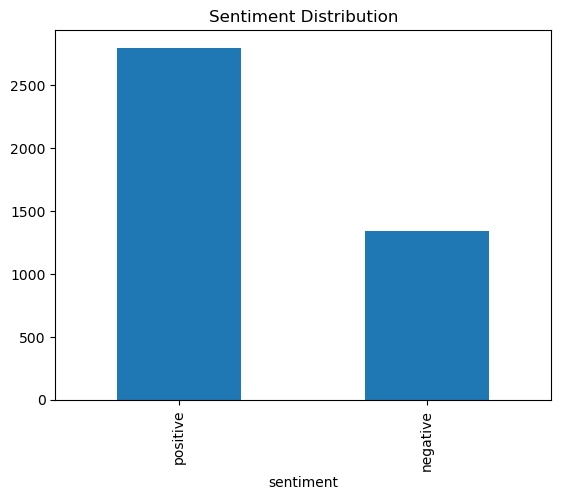

In [18]:
df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution')

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    df['processed_review'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9, encoding="utf-8", stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Empirical class_prior would just re-encode the imbalance —
# use uniform priors instead so the model doesn't lean on frequency alone
clf = MultinomialNB(class_prior=[1/2, 1/2])
clf.fit(X_train_vec, y_train)

y_pred = clf.predict(X_test_vec)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

    negative      0.685     0.413     0.515       269
    positive      0.763     0.909     0.830       560

    accuracy                          0.748       829
   macro avg      0.724     0.661     0.672       829
weighted avg      0.738     0.748     0.728       829



Confusion matrix visualization.

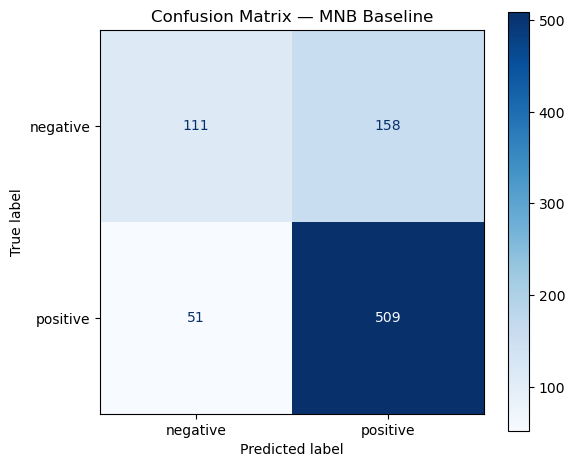

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test_vec)

labels = ['negative', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — MNB Baseline')
plt.tight_layout()
plt.show()

## Advanced: Transformer Fine-Tuning

Setup

In [23]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np
from sklearn.metrics import classification_report, precision_recall_fscore_support

label2id = {'negative': 0, 'positive': 1}
id2label = {v: k for k, v in label2id.items()}

train_df = pd.DataFrame({'text': X_train, 'label': y_train.map(label2id)})
test_df = pd.DataFrame({'text': X_test, 'label': y_test.map(label2id)})

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

Tokenization

In [24]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=512)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds = train_ds.rename_column('label', 'labels')
test_ds = test_ds.rename_column('label', 'labels')
train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

Map: 100%|██████████| 829/829 [00:00<00:00, 7643.95 examples/s]


Handling class imbalance

In [25]:
from torch import nn

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Inverse frequency weighting
class_counts = train_df['label'].value_counts().sort_index()
class_weights = torch.tensor(1.0 / class_counts.values, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(class_counts)

Model and Metrics

In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = (preds == labels).mean()
    return {'accuracy': acc, 'macro_f1': f1, 'macro_precision': precision, 'macro_recall': recall}

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11834.28it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training

In [27]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_dir='./logs',
    logging_steps=50,
    fp16=False,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [28]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.582733,0.534949,0.738239,0.719174,0.714595,0.737673
2,0.460749,0.528823,0.737033,0.718817,0.714658,0.738711
3,0.282720,0.597303,0.744270,0.726556,0.722081,0.746966
4,0.190994,0.770110,0.785283,0.753175,0.755299,0.751245
5,0.143916,0.822717,0.782871,0.757319,0.753040,0.762981


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.71it/s]


TrainOutput(global_step=1040, training_loss=0.35586876364854664, metrics={'train_runtime': 1620.7537, 'train_samples_per_second': 10.221, 'train_steps_per_second': 0.642, 'total_flos': 2194322458736640.0, 'train_loss': 0.35586876364854664, 'epoch': 5.0})

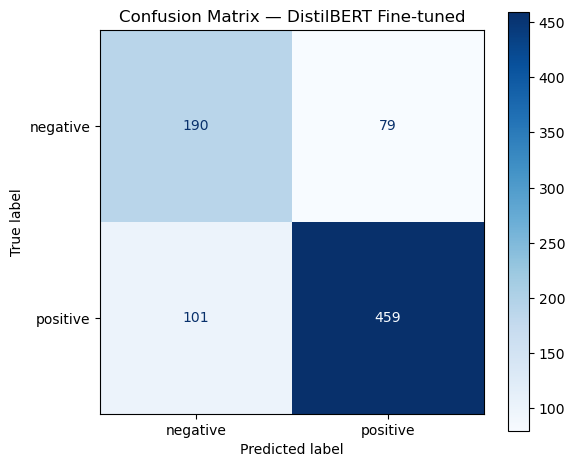

In [29]:
# confusion matrix for BERT model
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(test_ds)
logits = predictions.predictions
y_true_ids = predictions.label_ids
y_pred_ids = np.argmax(logits, axis=1)

# Map back to string labels for consistency with your MNB confusion matrix
y_true = [id2label[i] for i in y_true_ids]
y_pred = [id2label[i] for i in y_pred_ids]

labels = ['negative', 'positive']
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — DistilBERT Fine-tuned')
plt.tight_layout()
plt.show()